In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
# give colab access to google drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


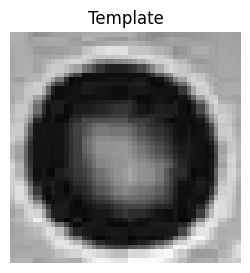

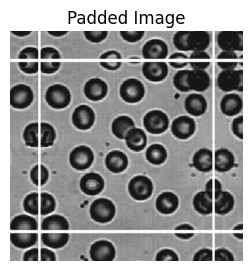

Found 66 peak candidates (threshold=0.25, neighborhood=17)
Candidates after mapping+mean-check: 42
Kept after NMS: 38


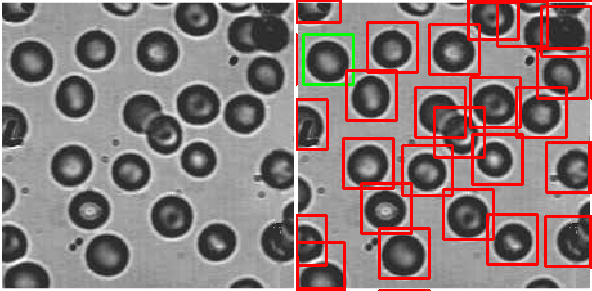

<Figure size 1200x600 with 0 Axes>

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'
img_bgr = cv2.imread(work_path + 'Data/thumbnail_blood.png')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# original selected template
template = img_gray[34:85, 7:58]
# coordinates of the selected template crop in the original image (top-left)
tmpl_x, tmpl_y = 7, 34

h, w = template.shape
H, W = img_gray.shape

# matching / filtering params
threshold = 0.25        # TM_CCOEFF_NORMED threshold (lower to catch weak/edge matches)
peak_neighborhood = max(3, min(h, w) // 3)  # neighborhood for local max suppression
edge_margin = 20        # px from border considered "edge band" for relaxed acceptance

# verification using patch statistics
patch_std_min = 7.0     # reject patches with very low std (likely empty/flat)
template_mean = float(template.mean())
mean_tol = 18.0         # allowed absolute difference between patch mean and template mean
strong_score_thresh = 0.45  # allow strong matches even if mean differs

# NMS
nms_iou_thresh = 0.30

# padding so the full template can be placed partially outside the original image
pad_top = h - 1
pad_bottom = h - 1
pad_left = w - 1
pad_right = w - 1

# ---------------- HELPERS ----------------
def nms_iou(detections, iou_thresh=0.3):
    # detections: Nx5 array (x1,y1,x2,y2,score)
    if len(detections) == 0:
        return np.empty((0,5))
    x1 = detections[:, 0].astype(float)
    y1 = detections[:, 1].astype(float)
    x2 = detections[:, 2].astype(float)
    y2 = detections[:, 3].astype(float)
    scores = detections[:, 4].astype(float)

    areas = (x2 - x1 + 1) * (y2 - y1 + 1)
    order = scores.argsort()[::-1]

    keep = []
    while order.size > 0:
        i = int(order[0])
        keep.append(i)
        if order.size == 1:
            break
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])

        w_ = np.maximum(0.0, xx2 - xx1 + 1)
        h_ = np.maximum(0.0, yy2 - yy1 + 1)
        inter = w_ * h_
        iou = inter / (areas[i] + areas[order[1:]] - inter + 1e-12)

        remaining = np.where(iou <= iou_thresh)[0]
        order = order[remaining + 1]
    return detections[keep].astype(int)

# ---------------- VISUALIZE TEMPLATE ----------------
plt.figure(figsize=(3,3))
plt.imshow(template, cmap='gray')
plt.title('Template')
plt.axis('off')

# ---------------- PAD IMAGE & MATCH ----------------
img_gray_p = cv2.copyMakeBorder(img_gray, pad_top, pad_bottom, pad_left, pad_right,
                                borderType=cv2.BORDER_REFLECT)

plt.figure(figsize=(3,3))
plt.imshow(img_gray_p, cmap='gray')
plt.title('Padded Image')
plt.axis('off')
plt.show()


res = cv2.matchTemplate(img_gray_p, template, cv2.TM_CCOEFF_NORMED)

# local peak detection
if peak_neighborhood % 2 == 0:
    peak_neighborhood += 1
kernel = np.ones((peak_neighborhood, peak_neighborhood), np.uint8)
res_dil = cv2.dilate(res, kernel)
peaks_mask = (res == res_dil) & (res >= threshold)
ys, xs = np.where(peaks_mask)
print(f"Found {len(xs)} peak candidates (threshold={threshold}, neighborhood={peak_neighborhood})")

# collect detections mapped to original image coordinates, with mean/std verification
dets = []
for (xp, yp) in zip(xs, ys):
    # patch in padded image coordinates
    patch = img_gray_p[yp:yp + h, xp:xp + w]
    if patch.shape != (h, w):
        # safety: skip malformed patches
        continue

    patch_mean = float(patch.mean())
    patch_std = float(patch.std())
    score = float(res[yp, xp])

    # simple verification:
    # - reject if patch is very flat (low std)
    # - reject if patch mean is far from template mean, unless the match score is strong
    if patch_std < patch_std_min:
        # likely empty or flat background -> reject
        continue
    if abs(patch_mean - template_mean) > mean_tol and score < strong_score_thresh:
        # mean differs substantially and score isn't strong -> reject
        continue

    # map padded top-left back to original image coords
    x = int(xp - pad_left)
    y = int(yp - pad_top)
    x1 = x
    y1 = y
    x2 = x + w - 1
    y2 = y + h - 1

    # Accept candidate if:
    # - it is interior (fully inside), OR
    # - it is partially outside the original image (partial template), OR
    # - it is within edge_margin of any border (near edge)
    partly_outside = (x1 < 0) or (y1 < 0) or (x2 >= W) or (y2 >= H)
    near_edge = (x1 < edge_margin) or (y1 < edge_margin) or (x2 >= W - edge_margin) or (y2 >= H - edge_margin)
    if partly_outside or near_edge or (0 <= x1 and 0 <= y1 and x2 < W and y2 < H):
        dets.append([x1, y1, x2, y2, score])

dets = np.array(dets, dtype=float)
print("Candidates after mapping+mean-check:", len(dets))

# ---------------- NMS & DRAW ----------------
if dets.size == 0:
    print("No detections after filtering.")
else:
    kept = nms_iou(dets, iou_thresh=nms_iou_thresh)
    print("Kept after NMS:", len(kept))

    result = img_bgr.copy()
    for (x1, y1, x2, y2, score) in kept:
        # clip for drawing
        cx1 = max(0, x1); cy1 = max(0, y1)
        cx2 = min(W-1, x2); cy2 = min(H-1, y2)
        # If this detection's top-left matches the selected template crop top-left, color green.
        if (x1 == tmpl_x) and (y1 == tmpl_y):
            color = (0, 255, 0)  # green
        else:
            color = (0, 0, 255)  # red
        cv2.rectangle(result, (cx1, cy1), (cx2, cy2), color, 2)

    concat = np.concatenate((img_bgr, result), axis=1)
    plt.figure(figsize=(12,6))
    cv2_imshow(concat)